# Distance and latency correlation analysis

This notebook explores the relationship between geographic distance and network latency in requests to Cloudflare's anycast network. By analyzing measurements from various vantage points, we aim to understand how distance affects latency.

## Dataset
The analysis uses `all_combined.csv`, which contains measurement data including:
- **Client Location**
- **Server Location**
- **Latency Metrics**

## Data loading and preprocessing

In [52]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.distance import geodesic, GreatCircleDistance
print("Imported libs")

Imported libs


In [53]:
df = ( 
    pl.read_csv("all_combined.csv", ignore_errors=True)
    .filter(pl.col('clientCountry') == pl.col('clientCountryAccordingCloudflare'))
    .with_columns(
        pl.from_epoch("timestamp", time_unit="s")
    )
)
print(f"Total measurements: {df.height}")
df.head()

Total measurements: 2034760


timestamp,balancerId,balancerIp,clientIpAccordingCloudflare,clientCountryAccordingCloudflare,balancerColocationCenter,targetDomain,scheme,httpVersion,tlsVersion,clientCountry,clientCity,clientAsn,clientNetwork,latencyTotal,latencyDNS,latencyTCP,latencyTLS,latencyFirstByte,latencyDownload
datetime[μs],str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64
2026-01-21 22:50:36,"""107f211""","""104.16.133.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",84,14,3,46,15,6
2026-01-21 22:50:36,"""107f156""","""104.16.133.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",78,11,1,18,37,11
2026-01-21 22:50:36,"""107f211""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",23,2,1,13,5,2
2026-01-21 22:50:37,"""107f179""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",27,1,1,14,10,1
2026-01-21 22:50:37,"""107f174""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",29,2,0,18,7,2


### Loading colocations
We need the `all_colocs.csv` file to determine server locations. We will use the `city` and `country` keys to find the coordinates for each colocation facility.

In [55]:
colocs = pl.read_csv("all_colocs.csv")
colocs.head()

colocationCenter,city,country
str,str,str
"""TIA""","""Tirana""","""Albania"""
"""ALG""","""Algiers""","""Algeria"""
"""AAE""","""Annaba""","""Algeria"""
"""ORN""","""Oran""","""Algeria"""
"""LAD""","""Luanda""","""Angola"""


### Loading cities
We use `worldcities.csv` to map cities and countries to their coordinates. However, we must manually filter out instances where a `city` and `country` combination yields multiple results. This process often removes several locations, particularly in the USA.

In [56]:
world_cities = pl.read_csv("worldcities.csv", ignore_errors=True)
world_cities = world_cities.filter(pl.len().over(["city_ascii", "iso2"]) == 1)
world_cities.head()

city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
str,str,f64,f64,str,str,str,str,str,i64,i64
"""Tokyo""","""Tokyo""",35.687,139.7495,"""Japan""","""JP""","""JPN""","""Tōkyō""","""primary""",37785000,1392685764
"""Jakarta""","""Jakarta""",-6.175,106.8275,"""Indonesia""","""ID""","""IDN""","""Jakarta""","""primary""",33756000,1360771077
"""Delhi""","""Delhi""",28.61,77.23,"""India""","""IN""","""IND""","""Delhi""","""admin""",32226000,1356872604
"""Guangzhou""","""Guangzhou""",23.13,113.26,"""China""","""CN""","""CHN""","""Guangdong""","""admin""",26940000,1156237133
"""Mumbai""","""Mumbai""",19.0761,72.8775,"""India""","""IN""","""IND""","""Mahārāshtra""","""admin""",24973000,1356226629


### Merging colocations to coordinates
We merge each colocation facility with one city in cities dataset by `city` and `country` key.

In [57]:
colocs_with_coords = (
    colocs
    .join(world_cities, left_on=["city", "country"], right_on=["city_ascii", "country"])
    .select(['colocationCenter','lat', 'lng'])
    .drop_nulls()
)
colocs_with_coords.head()

colocationCenter,lat,lng
str,f64,f64
"""NRT""",35.687,139.7495
"""CGK""",-6.175,106.8275
"""BOM""",19.0761,72.8775
"""MNL""",14.5958,120.9772
"""GRU""",-23.5504,-46.6339


## Latency Aggregation
We group measurements by the `Client City` -> `Server Colocation` pair. We calculate mean, median and min statistics for TLS 1.3 handshake. We filter for pairs with a statistically significant number of measurements (> 300).

In [58]:
client_server_latency = (
    df
    .filter(pl.col('latencyTCP') > 0)
    .group_by('balancerColocationCenter', 'clientCity', 'clientCountry')
    .agg(
        pl.col('latencyTCP').median().alias('latencyTCPMedian'),
        pl.col('latencyTCP').min().alias('latencyTCPMin'),
        pl.col('latencyFirstByte').median().alias('latencyFirstByteMedian'),
        pl.col('latencyFirstByte').min().alias('latencyFirstByteMin'),
        pl.len().alias('measures')
    )
    .join(world_cities, left_on=["clientCity", "clientCountry"], right_on=["city_ascii", "iso2"])
    .join(colocs_with_coords, left_on="balancerColocationCenter", right_on="colocationCenter", suffix="_server")
)

client_server_latency.head()

balancerColocationCenter,clientCity,clientCountry,latencyTCPMedian,latencyTCPMin,latencyFirstByteMedian,latencyFirstByteMin,measures,city,lat,lng,country,iso3,admin_name,capital,population,id,lat_server,lng_server
str,str,str,f64,i64,f64,i64,u32,str,f64,f64,str,str,str,str,i64,i64,f64,f64
"""NRT""","""Tokyo""","""JP""",2.0,1,8.0,3,36987,"""Tokyo""",35.687,139.7495,"""Japan""","""JPN""","""Tōkyō""","""primary""",37785000,1392685764,35.687,139.7495
"""CGK""","""Jakarta""","""ID""",1.0,1,5.0,3,11873,"""Jakarta""",-6.175,106.8275,"""Indonesia""","""IDN""","""Jakarta""","""primary""",33756000,1360771077,-6.175,106.8275
"""SIN""","""Jakarta""","""ID""",24.0,13,21.0,16,11193,"""Jakarta""",-6.175,106.8275,"""Indonesia""","""IDN""","""Jakarta""","""primary""",33756000,1360771077,1.3,103.8
"""DEL""","""Delhi""","""IN""",6.0,1,11.0,4,107,"""Delhi""",28.61,77.23,"""India""","""IND""","""Delhi""","""admin""",32226000,1356872604,28.6139,77.2089
"""BOM""","""Delhi""","""IN""",23.0,19,28.0,22,39,"""Delhi""",28.61,77.23,"""India""","""IND""","""Delhi""","""admin""",32226000,1356872604,19.0761,72.8775


## Latency vs. distance visualization
We calculate the `GreatCircleDistance` (orthodromic distance) between the client and the server using their coordinates. This represents the shortest path on the surface of the sphere.

We plot the median TCP and HTTP headers latency against the calculated distance. The red dashed line represents the theoretical latency limit bounded by the speed of light in fiber optic cables ($\approx 204,000$ km/s).

In [59]:
def calculate_distance(row):
    client_coords = (row["lat"], row["lng"])
    server_coords = (row["lat_server"], row["lng_server"])
    return GreatCircleDistance(client_coords, server_coords).kilometers

client_server_latency = client_server_latency.with_columns(
    distance = pl.struct(["lat", "lng", "lat_server", "lng_server"]).map_elements(
        calculate_distance, 
        return_dtype=pl.Float64
    )
)

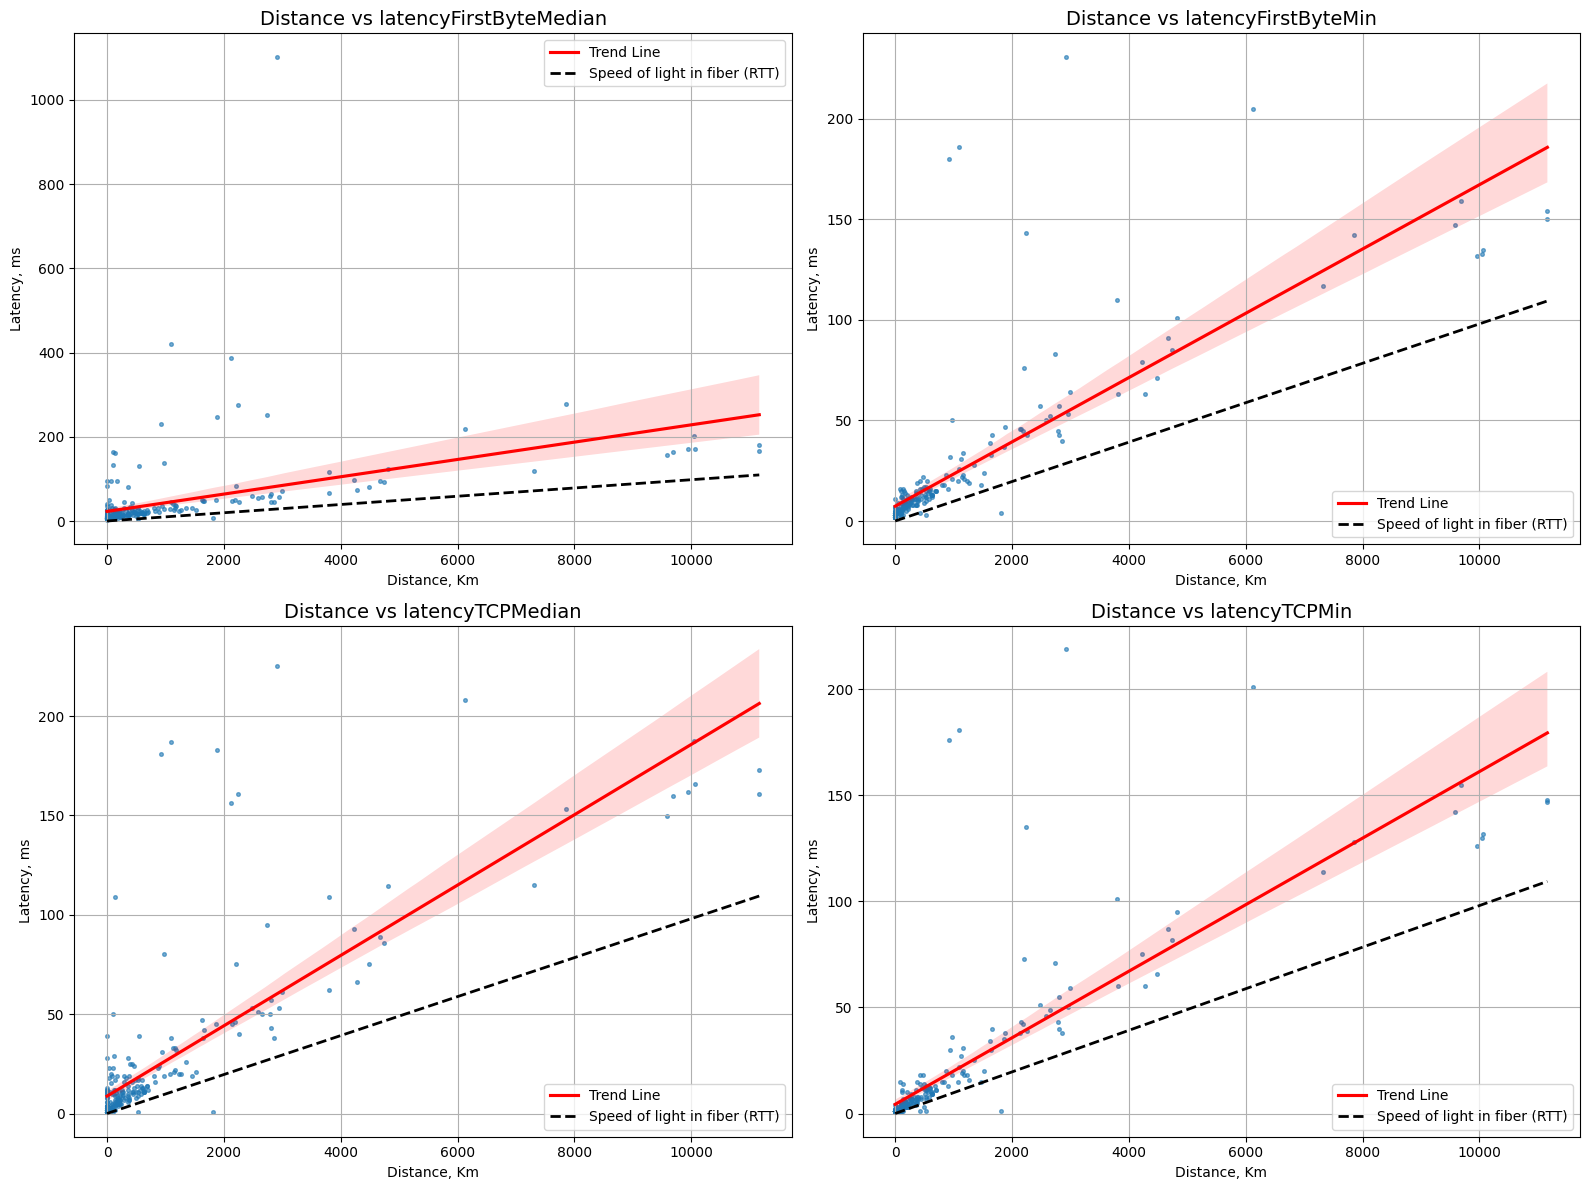

In [60]:
plot_data = client_server_latency.filter(
    pl.col("measures") > 100
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

latencyColumns = ['latencyFirstByteMedian', 'latencyFirstByteMin', 'latencyTCPMedian', 'latencyTCPMin']

max_dist = plot_data["distance"].max()
x_range = np.array([0, max_dist])
# time = (distance * 2) / speed_of_light in fiber
y_speed_of_light = (x_range * 2) / 204

for i, latencyColumn in enumerate(latencyColumns):
    ax = axes[i]
    
    sns.regplot(
        data=plot_data, 
        x="distance", 
        y=latencyColumn,
        ax=ax, 
        line_kws={"color": "red", "label": "Trend Line"},
        scatter_kws={"alpha": 0.6, "s": 7},
    )

    ax.plot(
        x_range, 
        y_speed_of_light, 
        label="Speed of light in fiber (RTT)", 
        color="black", 
        linestyle="--", 
        linewidth=2
    )

    ax.set_title(f"Distance vs {latencyColumn}", fontsize=14)
    ax.set_xlabel("Distance, Km")
    ax.set_ylabel("Latency, ms")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Routing inefficiency
We define verify routing efficiency by comparing measured minimal TCP latency to the theoretical minimum.
$$ \text{Inefficiency Factor} = \frac{\text{measured latency}}{\text{Theoretical Min RTT}} $$
Values close to 1.0 indicate near-perfect routing (impossible in practice due to equipment delays). Values > 3.0 often suggest circuitous routing paths.

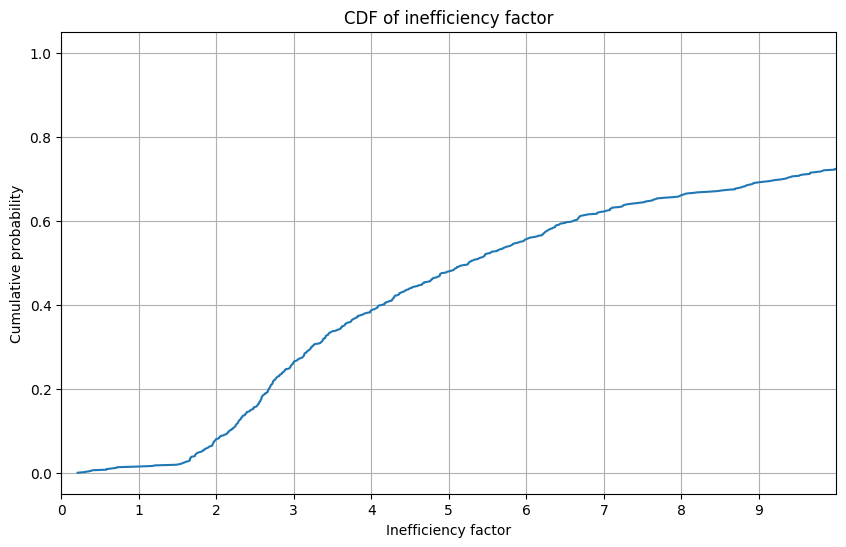

In [72]:

analysis_df = client_server_latency.filter(pl.col('distance') > 50).with_columns(
    theoretical_min_rtt = (2 * pl.col('distance')) / 204
).with_columns(
    inefficiency = pl.col('latencyFirstByteMedian') / pl.col('theoretical_min_rtt')
)

# Plot Cumulative Distribution Function (CDF) of Inefficiency
sorted_inefficiency = analysis_df['inefficiency'].sort()
p = 1. * np.arange(len(sorted_inefficiency)) / (len(sorted_inefficiency) - 1)

plt.figure(figsize=(10, 6))
plt.plot(sorted_inefficiency, p)
plt.xlim(0, 10)
plt.title("CDF of inefficiency factor")
plt.xlabel("Inefficiency factor")
plt.ylabel("Cumulative probability")
plt.xticks(np.arange(0, 10, 1))
plt.grid(True)
plt.show()